# Prueba 1 — Robustez: ¿por qué máscara neuronal (vs geométrico)?

Muestra que el MVDR **geométrico** se rompe con error de DOA y con desajuste de
sensor (autocancelación por WNG alto), mientras el **ciego** (NM-MVDR) adapta.
DS es el geométrico *robusto* (WNG bajo) → junto con el MVDR-geo encuadra el
trade-off de carga diagonal; el NM-MVDR le gana a toda esa recta.

- **2a** — error de DOA: afecta solo a DS y MVDR-geo (usan `source_pos`); NM-MVDR plano.
- **2b** — desajuste de sensor: dos barridos 1D (ganancia y fase por separado).

Fijos: **sin WPE** (robustez del filtro espacial puro), RT60=360 ms, iSIR=0, target broadside 0°/1 m.
Escenas: 2 locutores × 3 interferentes simultáneos cerca del target.

Es la **primera** prueba de la narrativa (beam → WPE+beam → WPE+beam+post) y **no depende de la Prueba 2** (no usa WPE).

**Correr en orden:** Setup → Config compartida → 2a → 2b → Figuras.

## Setup — ejecutar una vez por sesión de Colab
Montar Drive, clonar el repo, instalar dependencias y actualizar el código.

In [2]:
# Import the drive module from Google Colab
from google.colab import drive

# Mount Google Drive to the virtual machine
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 3. Descargar tu código temporalmente
%cd /content
!git clone https://github.com/MatiasVereert/Vision-Aided-Beamformer.git

/content
fatal: destination path 'Vision-Aided-Beamformer' already exists and is not an empty directory.


In [4]:
import os

WHL = "/content/drive/MyDrive/colab_wheels"   # cache persistente de wheels en Drive

# CONSTRUIR (git+ para las libs de GitHub).
BUILD = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "git+https://github.com/fgnt/pb_bss.git",
    "git+https://github.com/LCAV/pyroomacoustics.git",
    "git+https://github.com/fgnt/nara_wpe.git",
    "git+https://github.com/fakufaku/fast_bss_eval.git",
]
# INSTALAR desde cache: NOMBRES (no git+, si no pip vuelve a clonar).
INSTALL = [
    "noisereduce", "mir_eval", "pystoi", "pesq", "paderbox", "ai_edge_litert",
    "pb_bss", "pyroomacoustics", "nara_wpe", "fast_bss_eval",
]

# Reconstruye el cache SOLO si la lista de paquetes cambio (manifest) -> se
# autocura si agrego/saco un paquete, sin tener que borrar el cache a mano.
manifest = os.path.join(WHL, ".manifest.txt")
key = "\n".join(sorted(BUILD))
need_build = (not os.path.isfile(manifest)) or open(manifest).read() != key

if need_build:
    os.makedirs(WHL, exist_ok=True)
    print("[*] (Re)construyendo cache de wheels en Drive (una vez por cambio de lista)...")
    !pip wheel --wheel-dir=$WHL {" ".join(BUILD)}
    with open(manifest, "w") as fh:
        fh.write(key)
    print("[*] Cache actualizado en", WHL)

!pip install --no-index --find-links=$WHL {" ".join(INSTALL)}
print("[*] Paquetes instalados desde el cache de Drive.")
# Si Colab actualiza Python y falla un import:  !rm -rf $WHL  (se reconstruye solo)

Looking in links: /content/drive/MyDrive/colab_wheels
  Cloning https://github.com/jfsantos/SRMRpy to /tmp/pip-install-jr9euohn/srmrpy_69e90e38ea46476b9c83693e12e0407a
  Running command git clone --filter=blob:none --quiet https://github.com/jfsantos/SRMRpy /tmp/pip-install-jr9euohn/srmrpy_69e90e38ea46476b9c83693e12e0407a
  Resolved https://github.com/jfsantos/SRMRpy to commit fee009779cef96bed34db3a7e31d10f3ad1ea133
  Preparing metadata (setup.py) ... done
  Using cached https://github.com/detly/gammatone/archive/master.zip
  Preparing metadata (setup.py) ... done
[*] Paquetes instalados desde el cache de Drive.


In [5]:
%cd /content/Vision-Aided-Beamformer
!git pull origin main

/content/Vision-Aided-Beamformer
From https://github.com/MatiasVereert/Vision-Aided-Beamformer
 * branch            main       -> FETCH_HEAD
Already up to date.


## Config compartida

In [6]:
import sys, os, numpy as np, shutil
from datetime import datetime

repo_root = '/content/Vision-Aided-Beamformer'
src_path = os.path.join(repo_root, 'src')
for p in (repo_root, src_path):
    if p not in sys.path: sys.path.append(p)
%cd {src_path}

try:
    import tensorflow as tf
    TFLITE_AVAILABLE = True
except ImportError:
    TFLITE_AVAILABLE = False

from evaluation.full_benchmark_test_dtln_mird import run_mird_grid_search
from evaluation.bf_wrappers import DS, MVDR_Recursive, NM_MVDR
from propagation.mird_loader import MirdDatasetProvider

m1 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_1.tflite")
m2 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_2.tflite")
interpreter_1 = interpreter_2 = None
if TFLITE_AVAILABLE and os.path.exists(m1) and os.path.exists(m2):
    interpreter_1 = tf.lite.Interpreter(model_path=m1); interpreter_1.allocate_tensors()
    interpreter_2 = tf.lite.Interpreter(model_path=m2); interpreter_2.allocate_tensors()
    print("[*] DTLN TFLite OK.")
else:
    print("[*] Sin DTLN-mono (NM-MVDR usa su mascara interna).")

input_dir = "/content/drive/MyDrive/Benchmarks_tesis/inputs"
mird_dir  = "/content/drive/MyDrive/Benchmarks_tesis/rirs"
provider = MirdDatasetProvider(root_dir=mird_dir)

# ===================== PERILLAS =====================
WPE_DELAY = 2      # no se usa aca (esta prueba corre SIN WPE)
WPE_TAPS  = 5
DURATION  = 15
# ===================================================

TARGETS = [os.path.join(input_dir, f) for f in [
    "p002_emo_adoration_sentences.wav",
    "p008_emo_contentment_sentences.wav",
]]
INTERF = [os.path.join(input_dir, f) for f in [
    "techno_gated commune.wav",     # 0 musica
    "hairdryer_07_SH_MKH800.wav",   # 1 secadora
    "drill_07_RHODE_NT1.wav",       # 2 taladro
]]
# Layout FIJO: 3 interferentes simultaneos cerca del target (broadside 0).
INTERF_LAYOUT = [[(30, 1.0, 0), (-15, 1.0, 1), (45, 1.0, 2)]]

base_config = {
    'fs': 16000, 'duration': DURATION, 't_early': 0.008,
    'array_center': [3.0, 3.0, 1.2], 'mird_spacing': "3-3-3-8-3-3-3",
    'snr_db': 60.0,
    'source_path': TARGETS[0], 'interf_paths': INTERF,
    'wpe_taps': WPE_TAPS, 'wpe_delay': WPE_DELAY, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    'dtln_model_path': m1,
    'eval_references': ['early'],
}

processors_dict = {
    "DS":       DS(),                             # geometrico robusto
    "MVDR-geo": MVDR_Recursive(min_loading=1e-6), # geometrico adaptativo (fragil)
    "NM-MVDR":  NM_MVDR(min_loading=1e-6, alpha=0.99),
}

# Ejes FIJOS comunes a 2a y 2b.
FIXED = dict(rt60=[0.360], target_angle=[0], target_dist=[1.0],
             source_path=TARGETS, interf_configs=INTERF_LAYOUT,
             isir_db=[0], use_wpe=[False], wpe_taps=[WPE_TAPS], wpe_delay=[WPE_DELAY])

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M")
def run_dirs(name):
    t = f"/content/results_temp/P1_robustez_{name}_{RUN_TAG}"
    d = f"/content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_{name}_{RUN_TAG}"
    os.makedirs(t, exist_ok=True); os.makedirs(d, exist_ok=True)
    return t, d

def run(grid, name):
    t, d = run_dirs(name)
    df = run_mird_grid_search(grid_params=grid, dataset_provider=provider,
                              processors=processors_dict, scene_base_config=base_config,
                              output_dir=t, interpreter_1=interpreter_1, interpreter_2=interpreter_2, save_catalog=False)
    shutil.copytree(t, d, dirs_exist_ok=True)
    print(f"[EXITO] {name} -> {d}")
    return df, d

print("Config lista. delay* =", WPE_DELAY, "| targets =", len(TARGETS))

/content/Vision-Aided-Beamformer/src
[*] DTLN TFLite OK.
[MirdDatasetProvider] Successfully indexed 234 RIR files from: /content/drive/MyDrive/Benchmarks_tesis/rirs
Config lista. delay* = 2 | targets = 2


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 1a — Error de DOA (afecta solo DS y MVDR-geo)

In [7]:
grid_2a = dict(FIXED,
    mismatch_gain=[0], mismatch_phase=[0],
    error_angle_deg=[0, 2, 5, 10, 15],   # <-- barrido
    error_distance_m=[0.0],
)
df_2a, dir_2a = run(grid_2a, "2a_doa")

[*] t_early FIXED at 8.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 10 per processor.


Running MIRD Benchmark:   0%|          | 0/10 [00:00<?, ?exp/s]


--- Iteration 1/10 | Config: {'rt60': 0.36, 'target_angle': 0, 'target_dist': 1.0, 'source_path': '/content/drive/MyDrive/Benchmarks_tesis/inputs/p002_emo_adoration_sentences.wav', 'interf_configs': [(30, 1.0, 0), (-15, 1.0, 1), (45, 1.0, 2)], 'isir_db': 0, 'use_wpe': False, 'wpe_taps': 5, 'wpe_delay': 2, 'mismatch_gain': 0, 'mismatch_phase': 0, 'error_angle_deg': 0, 'error_distance_m': 0.0} ---
 -> [NODE 1] Physical setup changed. Extracting MIRD RIRs...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...


/content/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)


[Loader] Remuestreando de 44100 Hz a 16000 Hz...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[SimAcoustic: MIRD] Mapping Target Source -> Snapped to Grid: Dist=1.0m, Angle=0°
[SimAcoustic: MIRD] Mapping Interf #1 -> Snapped to Grid: Dist=1.0m, Angle=30°
[SimAcoustic: MIRD] Mapping Interf #2 -> Snapped to Grid: Dist=1.0m, Angle=-15°
[SimAcoustic: MIRD] Mapping Interf #3 -> Snapped to Grid: Dist=1.0m, Angle=45°
[SimAcoustic] Triggering high-fidelity RIR resampling: 48000 Hz -> 16000 Hz
[SimAcoustic] Successfully loaded and synchronized real dataset environment spanning 8 sensor channels.


...

   -> Processing with: NM-MVDR (ErrAng: 15deg, ErrDist: 0.0m)...
 -> Computing DTLN mask (sharpen_exp=4.0) for ref channel 4...
Processing frame 1871 of 1872

Running MIRD Benchmark:  90%|█████████ | 9/10 [03:28<00:19, 19.81s/exp]

   -> [NODE 6] Applying DTLN post NM-MVDR...


Running MIRD Benchmark: 100%|██████████| 10/10 [03:31<00:00, 21.12s/exp]



=== BATCH COMPLETED IN 3.52 MINUTES ===
[EXITO] 2a_doa -> /content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_2a_doa_20260801_1436


## 1b — Desajuste de sensor (ganancia y fase por separado)

In [8]:
# Dos barridos 1D en L (no el producto cruzado): ganancia | fase.
grid_2b_gain = dict(FIXED,
    error_angle_deg=[0.0], error_distance_m=[0.0],
    mismatch_gain=[0, 1, 2, 3], mismatch_phase=[0],     # <-- ganancia
)
grid_2b_phase = dict(FIXED,
    error_angle_deg=[0.0], error_distance_m=[0.0],
    mismatch_gain=[0], mismatch_phase=[0, 3, 6, 10],    # <-- fase
)
df_2b_gain,  dir_2b_gain  = run(grid_2b_gain,  "2b_gain")
df_2b_phase, dir_2b_phase = run(grid_2b_phase, "2b_phase")

[*] t_early FIXED at 8.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 8 per processor.


Running MIRD Benchmark:   0%|          | 0/8 [00:00<?, ?exp/s]


--- Iteration 1/8 | Config: {'rt60': 0.36, 'target_angle': 0, 'target_dist': 1.0, 'source_path': '/content/drive/MyDrive/Benchmarks_tesis/inputs/p002_emo_adoration_sentences.wav', 'interf_configs': [(30, 1.0, 0), (-15, 1.0, 1), (45, 1.0, 2)], 'isir_db': 0, 'use_wpe': False, 'wpe_taps': 5, 'wpe_delay': 2, 'error_angle_deg': 0.0, 'error_distance_m': 0.0, 'mismatch_gain': 0, 'mismatch_phase': 0} ---
 -> [NODE 1] Physical setup changed. Extracting MIRD RIRs...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[Loader] Remuestreando de 44100 Hz a 16000 Hz...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[Loader] Remuestreando de 48000 Hz a 16000 Hz...
[Loader] Audio corto, repitiendo en bucle para llenar duración...
[SimAcoustic: MIRD] Mapping Target Source -> Snapped to Grid: Dist=1.0m, Angle=0°
[SimAcoustic: MIRD] Mapping Interf #1 -> Snapped to Grid: Dist

Running MIRD Benchmark:   0%|          | 0/8 [00:04<?, ?exp/s]

[SimAcoustic] Signals successfully convolved and split (Early/Late).
 -> [NODE 2] Applying acoustic mixture (iSIR = 0 dB)...
[SimAcoustic] Mixture completed with iSIR: 0 dB.
 -> [NODE 3] Emulating hardware (Gain: 0dB, Phase: 0deg)...
[Microphone] Custom errors set -> Gain std: 0dB | Phase std: 0deg | SNR: 60.0dBA


...

   -> Processing with: NM-MVDR (ErrAng: 0.0deg, ErrDist: 0.0m)...
 -> Computing DTLN mask (sharpen_exp=4.0) for ref channel 4...
Processing frame 1871 of 1872

Running MIRD Benchmark:  88%|████████▊ | 7/8 [03:10<00:23, 23.91s/exp]

   -> [NODE 6] Applying DTLN post NM-MVDR...


Running MIRD Benchmark: 100%|██████████| 8/8 [03:11<00:00, 23.99s/exp]


=== BATCH COMPLETED IN 3.20 MINUTES ===
[EXITO] 2b_phase -> /content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_2b_phase_20260801_1436


## Figuras — curvas 1D (el cruce geométrico → ciego)

-> /content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_2a_doa_20260801_1436/curvas.png


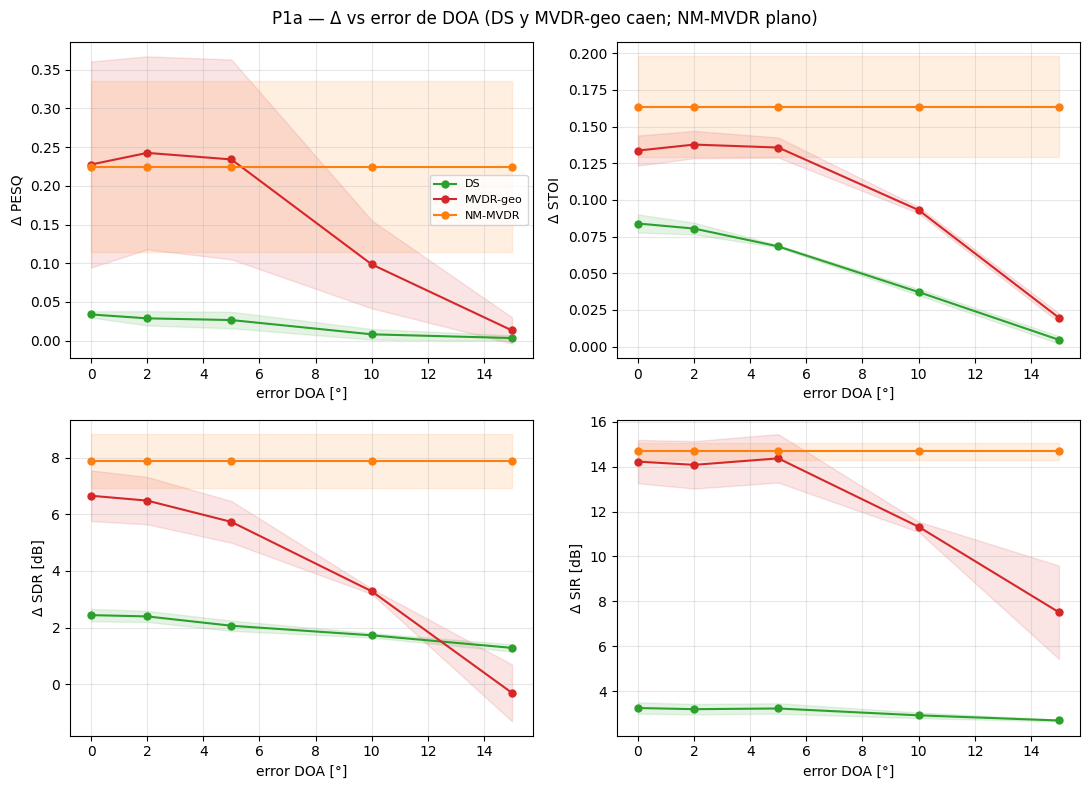

-> /content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_2b_gain_20260801_1436/curvas.png


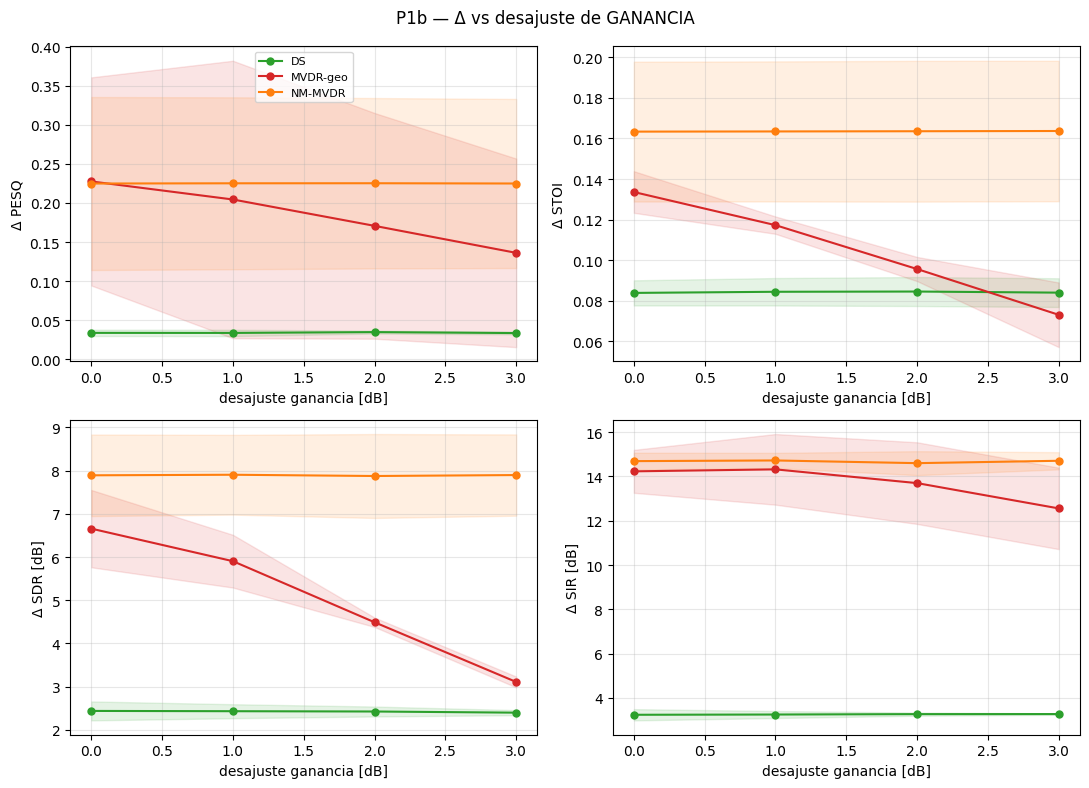

-> /content/drive/MyDrive/Tesis_Beamformers/results/P1_robustez_2b_phase_20260801_1436/curvas.png


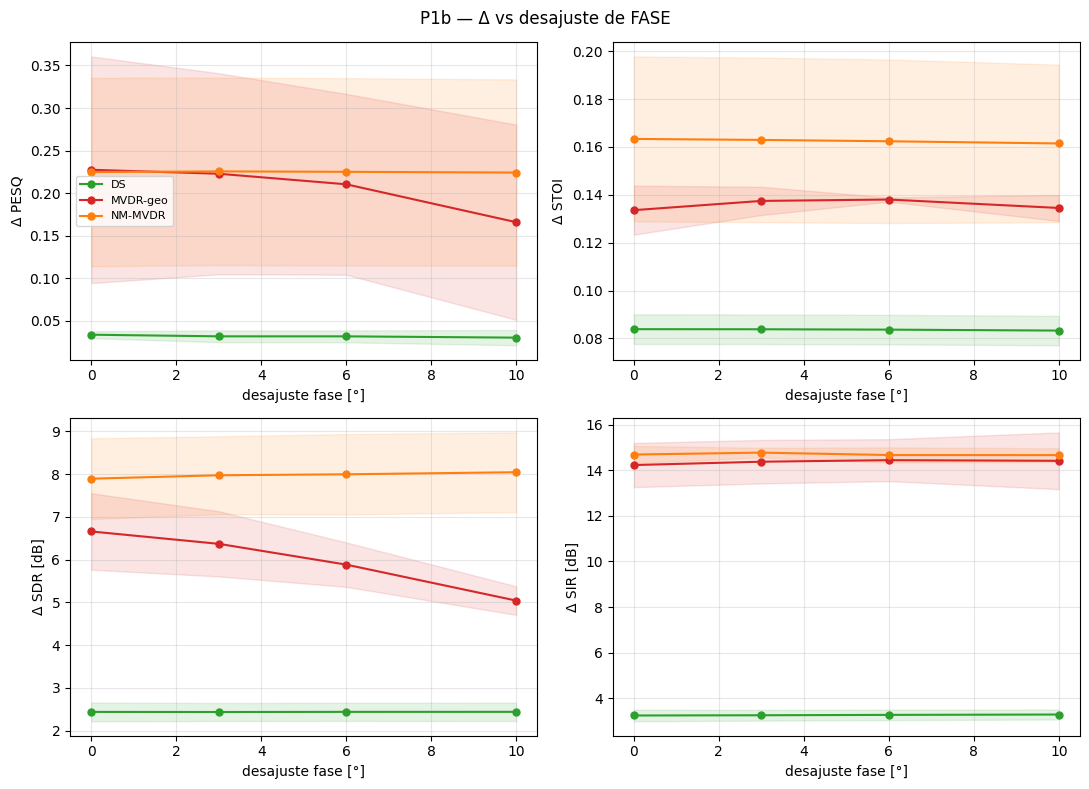

In [9]:
import matplotlib.pyplot as plt

METRICS = [("Delta_tot_PESQ_early","Δ PESQ"), ("Delta_tot_STOI_early","Δ STOI"),
           ("Delta_tot_SDR_early","Δ SDR [dB]"), ("Delta_tot_SIR_early","Δ SIR [dB]")]
PROCS  = ["DS","MVDR-geo","NM-MVDR"]
COLORS = {"DS":"tab:green","MVDR-geo":"tab:red","NM-MVDR":"tab:orange"}

def plot_curves(df, xcol, xlabel, title, outdir):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax,(col,lbl) in zip(axes.ravel(), METRICS):
        if col not in df.columns: continue
        for pr in PROCS:
            sub = df[df.processor==pr]
            if sub.empty: continue
            g = sub.groupby(xcol)[col]
            m, s = g.mean(), g.std()
            ax.plot(m.index.values, m.values, "-o", color=COLORS[pr], ms=5, label=pr)
            ax.fill_between(m.index.values, (m-s).values, (m+s).values,
                            color=COLORS[pr], alpha=0.12)
        ax.set_xlabel(xlabel); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
    axes.ravel()[0].legend(fontsize=8, loc="best")
    fig.suptitle(title); fig.tight_layout()
    png = os.path.join(outdir, "curvas.png")
    fig.savefig(png, dpi=140, bbox_inches="tight"); print("->", png)
    plt.show()

# 2a: DOA
plot_curves(df_2a, "error_angle_deg", "error DOA [°]",
            "P1a — Δ vs error de DOA (DS y MVDR-geo caen; NM-MVDR plano)", dir_2a)
# 2b: ganancia y fase
plot_curves(df_2b_gain,  "mismatch_gain",  "desajuste ganancia [dB]",
            "P1b — Δ vs desajuste de GANANCIA", dir_2b_gain)
plot_curves(df_2b_phase, "mismatch_phase", "desajuste fase [°]",
            "P1b — Δ vs desajuste de FASE", dir_2b_phase)